In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "master_US.csv"

df = pd.read_csv(CSV_PATH)
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Keep all columns originally
data = df.copy()

print(data.head())

print(data.info())

        DATE  working_hour_manuf    CPI  Ids_Prd  R_Csump  Ef_Fed_Rate  \
0 1960-01-01                40.6  29.37  24.2078   15.789         3.99   
1 1960-02-01                40.3  29.41  23.9924   15.858         3.97   
2 1960-03-01                40.0  29.41  23.7770   16.083         3.84   
3 1960-04-01                40.0  29.54  23.5885   16.331         3.92   
4 1960-05-01                40.1  29.57  23.5616   16.002         3.85   

   Intr_10Y  Unemp     M2     M1  Labor_partic  Per_savings  All_Emp  \
0      4.72    5.2  298.2  140.0          59.1         10.9    54274   
1      4.49    4.8  298.4  139.9          59.1         10.6    54513   
2      4.25    5.4  299.3  139.8          58.5          9.4    54454   
3      4.28    5.2  300.1  139.6          59.5          8.4    54813   
4      4.35    5.1  300.9  139.6          59.5         10.4    54475   

   Moody_aaa  NetExports      ^GSPC  Real GDP  Customs_Duties  Imports_Goods  \
0       4.61         NaN  58.029000  3517.

In [2]:
# create tariff rate raw number, only quarterly though
data["tariff_rate_raw"] = data["Customs_Duties"] / data["Imports_Goods"]

#filter data just for after 2000
current_data = data.where(data["DATE"] >= "1999-01-01")

#some command so that we dont fill with all nas
current_data = current_data.dropna(subset=["DATE"]).reset_index(drop=True)

# fill in blanks using linear method
current_data["tariff_rate"] = current_data["tariff_rate_raw"].interpolate(method = "linear")
current_data["Customs_Duties"] = current_data["Customs_Duties"].interpolate(method = "linear")
current_data["Imports_Goods"] = current_data["Imports_Goods"].interpolate(method = "linear")
current_data["GDP_nominal"] = current_data["GDP_nominal"].interpolate(method = "linear")
current_data["Real GDP"] = current_data["Real GDP"].interpolate(method = "linear")

print(current_data.head())

        DATE  working_hour_manuf    CPI  Ids_Prd  R_Csump  Ef_Fed_Rate  \
0 1999-01-01                41.3  164.7  87.4949   64.013         4.63   
1 1999-02-01                41.4  164.7  88.0270   64.316         4.76   
2 1999-03-01                41.3  164.8  88.2267   64.624         4.81   
3 1999-04-01                41.3  165.9  88.4295   65.011         4.74   
4 1999-05-01                41.4  166.0  88.9886   65.311         4.74   

   Intr_10Y  Unemp      M2      M1  ...   All_Emp  Moody_aaa  NetExports  \
0      4.72    4.3  4403.0  1098.1  ...  127699.0       6.24     78473.0   
1      5.00    4.4  4425.8  1096.7  ...  128117.0       6.40     78212.0   
2      5.23    4.2  4432.6  1096.6  ...  128234.0       6.62     78701.0   
3      5.18    4.3  4461.4  1101.6  ...  128595.0       6.64     79530.0   
4      5.54    4.2  4486.1  1103.8  ...  128813.0       6.93     79539.0   

         ^GSPC      Real GDP  Customs_Duties  Imports_Goods  GDP_nominal  \
0  1248.774735  13315.

In [3]:
forecast_horizon = 12
# we want to predict the CPI 12 months from now (valuable for businesses)
current_data["cpi_future"] = current_data["CPI"].shift(-forecast_horizon)

#create shifted tariff rates - so in month a, the row has the current tariff rate / 
#tariff rate 3 months before, 6 months before, and 12 months before /
# this enables that we can use old tariff rates to predict current CPIs
current_data["tau_lag_3"] = current_data["tariff_rate"].shift(3)
current_data["tau_lag_6"] = current_data["tariff_rate"].shift(6)
current_data["tau_lag_12"] = current_data["tariff_rate"].shift(12)

# repeat with CPI so we can use old price levels to predict current price levels
current_data["cpi_lag_3"] = current_data["CPI"].shift(1)
current_data["cpi_lag_6"] = current_data["CPI"].shift(3)
current_data["cpi_lag_12"] = current_data["CPI"].shift(12)

#filter data just for after 2020
century_data = current_data.where(current_data["DATE"] >= "2000-01-01")
century_data = century_data.dropna(subset=["DATE"]).reset_index(drop=True)

print(century_data.head())

        DATE  working_hour_manuf    CPI  Ids_Prd  R_Csump  Ef_Fed_Rate  \
0 2000-01-01                41.5  169.3  91.5380   67.481         5.45   
1 2000-02-01                41.5  170.0  91.8239   68.116         5.73   
2 2000-03-01                41.4  171.0  92.1504   68.451         5.85   
3 2000-04-01                41.6  170.9  92.6989   68.431         6.02   
4 2000-05-01                41.2  171.2  92.9499   68.688         6.27   

   Intr_10Y  Unemp      M2      M1  ...   GDP_nominal  tariff_rate_raw  \
0      6.66    4.0  4667.6  1122.1  ...  10002.179000         0.016715   
1      6.52    4.1  4680.9  1108.6  ...  10084.026000              NaN   
2      6.26    4.0  4711.7  1107.5  ...  10165.873000              NaN   
3      5.99    3.8  4767.8  1115.6  ...  10247.720000         0.017820   
4      6.44    4.0  4755.7  1104.9  ...  10271.201667              NaN   

   tariff_rate  cpi_future  tau_lag_3  tau_lag_6  tau_lag_12  cpi_lag_3  \
0     0.016715       175.6   0.0186

In [52]:
#for random split
'''target_col = "cpi_future"

feature_cols = [col for col in century_data.columns if col not in ["DATE", target_col]]

model_data = century_data[["DATE"] + feature_cols + [target_col]].dropna().reset_index(drop=True)

X = model_data[feature_cols]
y = model_data[target_col]
dates = model_data["DATE"]

print(X.isna().sum().sum(), y.isna().sum())
print("Number of features:", len(feature_cols))
print(feature_cols)

#for chronological split
'''
target_col = "cpi_future"

exclude_cols = ["DATE", target_col, "tariff_rate_raw"]
feature_cols = [col for col in century_data.columns if col not in exclude_cols]

X = century_data[feature_cols]
y = century_data[target_col]

print("Number of features:", len(feature_cols))
print(feature_cols)



Number of features: 26
['working_hour_manuf', 'CPI', 'Ids_Prd', 'R_Csump', 'Ef_Fed_Rate', 'Intr_10Y', 'Unemp', 'M2', 'M1', 'Labor_partic', 'Per_savings', 'All_Emp', 'Moody_aaa', 'NetExports', '^GSPC', 'Real GDP', 'Customs_Duties', 'Imports_Goods', 'GDP_nominal', 'tariff_rate', 'tau_lag_3', 'tau_lag_6', 'tau_lag_12', 'cpi_lag_3', 'cpi_lag_6', 'cpi_lag_12']


In [54]:
# creating split based on chronological order
n = len(century_data)

#create 70 train, 20 validation, 10 test
train_end = int(n * 0.7)
val_end = int(n * 0.9)

#for feature columns
X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

#for date column
dates_train = century_data["DATE"].iloc[:train_end]
dates_val = century_data["DATE"].iloc[train_end:val_end]
dates_test = century_data["DATE"].iloc[val_end:]

In [ ]:
'''from sklearn.model_selection import train_test_split

#split not chronologically and use a random state - learning to deal with times like COVID

# first split: 70% train, 30% temp
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp, dates_train, dates_temp = train_test_split(
    X,
    y,
    dates,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test, dates_val, dates_test = train_test_split(
    X_temp,
    y_temp,
    dates_temp,
    test_size=1/3,
    random_state=42,
    shuffle=True
)


print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print(X_train)'''


Train shape: (69, 27)
Validation shape: (20, 27)
Test shape: (10, 27)
    working_hour_manuf      CPI   Ids_Prd  R_Csump  Ef_Fed_Rate  Intr_10Y  \
94                40.7  304.609  100.9067  117.816         5.12      3.90   
30                41.3  207.603  101.6672   84.666         5.26      5.00   
28                41.0  203.437   99.8346   84.127         5.25      4.76   
89                41.3  288.561  101.4400  114.632         0.33      2.75   
5                 40.4  176.400   90.7891   70.094         4.80      5.14   
..                 ...      ...       ...      ...          ...       ...   
60                42.0  234.747  102.8905   93.936         0.11      1.88   
71                42.0  246.626  101.0247  100.650         1.15      2.36   
14                40.1  183.700   91.1185   75.008         1.01      3.98   
92                41.1  300.420  100.5050  116.635         4.33      3.53   
51                41.5  231.638   97.7193   88.050         0.16      1.75   

    U

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#scale values
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X Train shape:", X_train_scaled.shape)
print("X Validation shape:", X_val_scaled.shape)
print("X Test shape:", X_test_scaled.shape)
print("y Train shape:", y_train.shape)
print("y Validation shape:", y_val.shape)
print("y Test shape:", y_test.shape)
print(X_train_scaled)


#scaling above is for chronological split
'''
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(X_train_scaled.isna().sum().sum(), y_train.isna().sum())'''


X Train shape: (218, 26)
X Validation shape: (62, 26)
X Test shape: (32, 26)
y Train shape: (218,)
y Validation shape: (62,)
y Test shape: (32,)
     working_hour_manuf       CPI   Ids_Prd   R_Csump  Ef_Fed_Rate  Intr_10Y  \
0              0.538886 -1.804434 -0.928063 -1.905481     1.843474  2.513223   
1              0.538886 -1.774489 -0.867102 -1.833573     1.983267  2.400993   
2              0.388467 -1.731711 -0.797483 -1.795638     2.043177  2.192566   
3              0.689304 -1.735989 -0.680527 -1.797903     2.128051  1.976123   
4              0.087629 -1.723156 -0.627007 -1.768800     2.252866  2.336862   
..                  ...       ...       ...       ...          ...       ...   
213            1.290980  1.503428  1.094766  1.850609    -0.303333 -0.933840   
214            1.441398  1.531576  1.146304  1.913118    -0.298341 -0.941857   
215            0.990142  1.553863  1.188523  2.002579    -0.228445 -0.901774   
216            1.140561  1.598952  1.188118  1.990575  

'\nfrom sklearn.preprocessing import StandardScaler\nimport pandas as pd\n\nscaler = StandardScaler()\n\nX_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)\nX_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)\nX_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)\n\nprint(X_train_scaled.isna().sum().sum(), y_train.isna().sum())'

In [57]:
#%pip install xgboost
from xgboost import XGBRegressor

# random parameters - may tweak later
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# predict values for validation set, compute MAE, RMSE, R2
y_val_pred = xgb_model.predict(X_val)

print("Validation MAE:", mean_absolute_error(y_val, y_val_pred))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Validation R^2:", r2_score(y_val, y_val_pred))


Validation MAE: 27.410123131536672
Validation RMSE: 34.23585891999764
Validation R^2: -1.7850628539734066


In [59]:
val_results = pd.DataFrame({
    "DATE": dates_val.values,
    "actual_cpi": y_val.values,
    "predicted_cpi": y_val_pred
})

val_results["error"] = val_results["predicted_cpi"] - val_results["actual_cpi"]
val_results["abs_error"] = val_results["error"].abs()

val_results = val_results.sort_values("DATE").reset_index(drop=True)

print(val_results.to_string(index=False))

'''val_results = century_data.iloc[train_end:val_end][["DATE"]].copy()
val_results["actual_cpi"] = y_val.values
val_results["predicted_cpi"] = y_val_pred
val_results["error"] = val_results["predicted_cpi"] - val_results["actual_cpi"]
val_results["abs_error"] = val_results["error"].abs()

print(val_results.to_string(index=False))'''


      DATE  actual_cpi  predicted_cpi      error  abs_error
2018-03-01     254.277     252.164398  -2.112602   2.112602
2018-04-01     255.233     252.164398  -3.068602   3.068602
2018-05-01     255.296     252.164398  -3.131602   3.131602
2018-06-01     255.213     252.164398  -3.048602   3.048602
2018-07-01     255.802     252.164398  -3.637602   3.637602
2018-08-01     256.036     252.164398  -3.871602   3.871602
2018-09-01     256.430     252.164398  -4.265602   4.265602
2018-10-01     257.155     252.164398  -4.990602   4.990602
2018-11-01     257.879     252.164398  -5.714602   5.714602
2018-12-01     258.630     252.164398  -6.465602   6.465602
2019-01-01     259.127     252.165436  -6.961564   6.961564
2019-02-01     259.250     252.165436  -7.084564   7.084564
2019-03-01     258.076     252.165436  -5.910564   5.910564
2019-04-01     256.032     252.165436  -3.866564   3.866564
2019-05-01     255.802     252.165436  -3.636564   3.636564
2019-06-01     257.042     252.165436  -

'val_results = century_data.iloc[train_end:val_end][["DATE"]].copy()\nval_results["actual_cpi"] = y_val.values\nval_results["predicted_cpi"] = y_val_pred\nval_results["error"] = val_results["predicted_cpi"] - val_results["actual_cpi"]\nval_results["abs_error"] = val_results["error"].abs()\n\nprint(val_results.to_string(index=False))'

In [60]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.to_string(index=False))


           feature  importance
                M2    0.355826
       GDP_nominal    0.278126
        cpi_lag_12    0.142749
               CPI    0.103556
         cpi_lag_3    0.037542
           R_Csump    0.036603
                M1    0.014217
         cpi_lag_6    0.008724
          Real GDP    0.008182
           Ids_Prd    0.005537
      Labor_partic    0.002945
working_hour_manuf    0.001318
       Ef_Fed_Rate    0.000842
             Unemp    0.000633
           All_Emp    0.000609
        NetExports    0.000601
         Moody_aaa    0.000590
     Imports_Goods    0.000424
             ^GSPC    0.000417
    Customs_Duties    0.000308
         tau_lag_6    0.000091
        tau_lag_12    0.000067
       tariff_rate    0.000053
       Per_savings    0.000017
          Intr_10Y    0.000015
         tau_lag_3    0.000009


In [61]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [62]:
y_val_pred_lasso = lasso_model.predict(X_val_scaled)

print("Validation MAE:", mean_absolute_error(y_val, y_val_pred_lasso))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred_lasso)))
print("Validation R^2:", r2_score(y_val, y_val_pred_lasso))

Validation MAE: 17.333990900443602
Validation RMSE: 20.44562449723763
Validation R^2: 0.006716307474468386


In [63]:
val_results_lasso = pd.DataFrame({
    "DATE": dates_val.values,
    "actual_cpi": y_val.values,
    "predicted_cpi": y_val_pred_lasso
})

val_results_lasso["error"] = val_results_lasso["predicted_cpi"] - val_results_lasso["actual_cpi"]
val_results_lasso["abs_error"] = val_results_lasso["error"].abs()

val_results_lasso = val_results_lasso.sort_values("DATE").reset_index(drop=True)

print(val_results_lasso.to_string(index=False))

'''val_results_lasso = century_data.iloc[train_end:val_end][["DATE"]].copy()
val_results_lasso["actual_cpi"] = y_val.values
val_results_lasso["predicted_cpi"] = y_val_pred_lasso
val_results_lasso["error"] = val_results_lasso["predicted_cpi"] - val_results_lasso["actual_cpi"]
val_results_lasso["abs_error"] = val_results_lasso["error"].abs()

print(val_results_lasso.to_string(index=False))'''

      DATE  actual_cpi  predicted_cpi      error  abs_error
2018-03-01     254.277     255.398252   1.121252   1.121252
2018-04-01     255.233     256.273977   1.040977   1.040977
2018-05-01     255.296     256.158388   0.862388   0.862388
2018-06-01     255.213     256.924743   1.711743   1.711743
2018-07-01     255.802     257.039581   1.237581   1.237581
2018-08-01     256.036     257.353360   1.317360   1.317360
2018-09-01     256.430     256.828939   0.398939   0.398939
2018-10-01     257.155     258.174332   1.019332   1.019332
2018-11-01     257.879     258.415028   0.536028   0.536028
2018-12-01     258.630     258.228310  -0.401690   0.401690
2019-01-01     259.127     258.572979  -0.554021   0.554021
2019-02-01     259.250     255.554601  -3.695399   3.695399
2019-03-01     258.076     254.583874  -3.492126   3.492126
2019-04-01     256.032     252.068103  -3.963897   3.963897
2019-05-01     255.802     252.114831  -3.687169   3.687169
2019-06-01     257.042     252.015865  -

'val_results_lasso = century_data.iloc[train_end:val_end][["DATE"]].copy()\nval_results_lasso["actual_cpi"] = y_val.values\nval_results_lasso["predicted_cpi"] = y_val_pred_lasso\nval_results_lasso["error"] = val_results_lasso["predicted_cpi"] - val_results_lasso["actual_cpi"]\nval_results_lasso["abs_error"] = val_results_lasso["error"].abs()\n\nprint(val_results_lasso.to_string(index=False))'

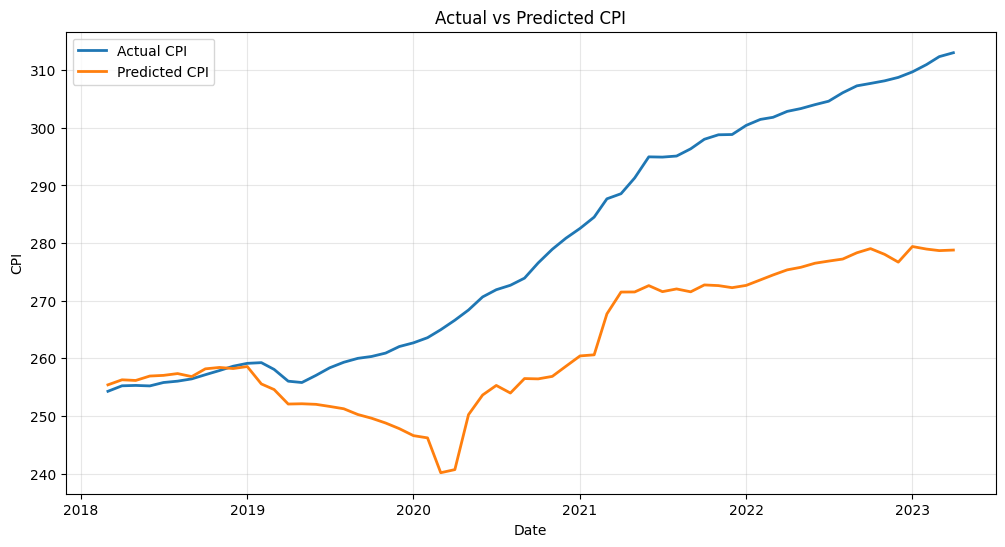

In [64]:
import matplotlib.pyplot as plt

plot_data = val_results_lasso.sort_values("DATE").copy()

plt.figure(figsize=(12, 6))
plt.plot(plot_data["DATE"], plot_data["actual_cpi"], label="Actual CPI", linewidth=2)
plt.plot(plot_data["DATE"], plot_data["predicted_cpi"], label="Predicted CPI", linewidth=2)

plt.title("Actual vs Predicted CPI")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


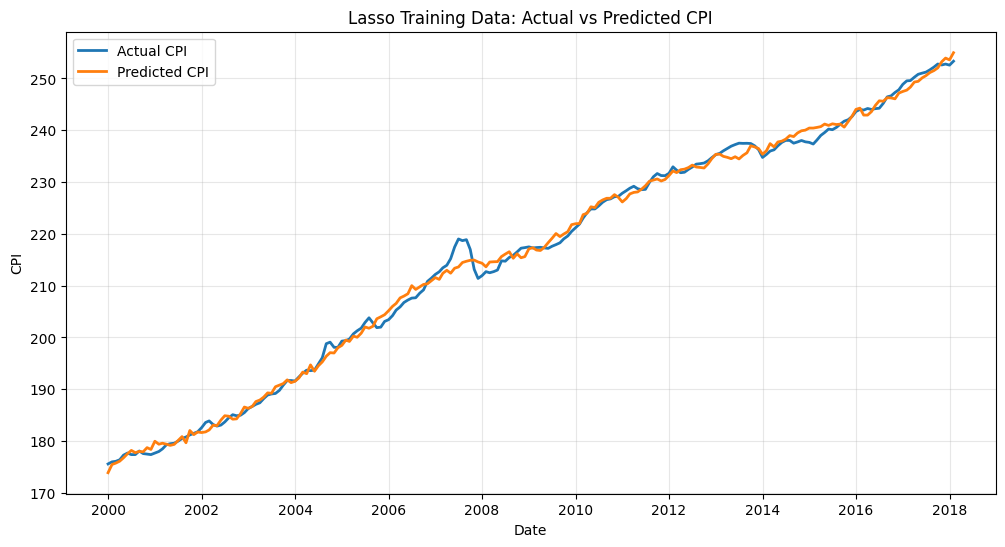

In [66]:
y_train_pred_lasso = lasso_model.predict(X_train_scaled)


train_results_lasso = pd.DataFrame({
    "DATE": dates_train.values,
    "actual_cpi": y_train.values,
    "predicted_cpi": y_train_pred_lasso
}).sort_values("DATE").reset_index(drop=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_results_lasso["DATE"], train_results_lasso["actual_cpi"], label="Actual CPI", linewidth=2)
plt.plot(train_results_lasso["DATE"], train_results_lasso["predicted_cpi"], label="Predicted CPI", linewidth=2)

plt.title("Lasso Training Data: Actual vs Predicted CPI")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [51]:
lasso_importance = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": lasso_model.coef_,
    "abs_coefficient": np.abs(lasso_model.coef_)
}).sort_values("abs_coefficient", ascending=False)

lasso_importance

,feature,coefficient,abs_coefficient
3,R_Csump,16.359414,16.359414
1,CPI,9.378393,9.378393
8,M1,8.005791,8.005791
25,cpi_lag_6,4.150000,4.150000
13,NetExports,3.695031,3.695031
6,Unemp,2.916290,2.916290
22,tau_lag_6,-2.518552,2.518552
17,Imports_Goods,-2.030609,2.030609
18,GDP_nominal,1.986060,1.986060
12,Moody_aaa,-1.864059,1.864059


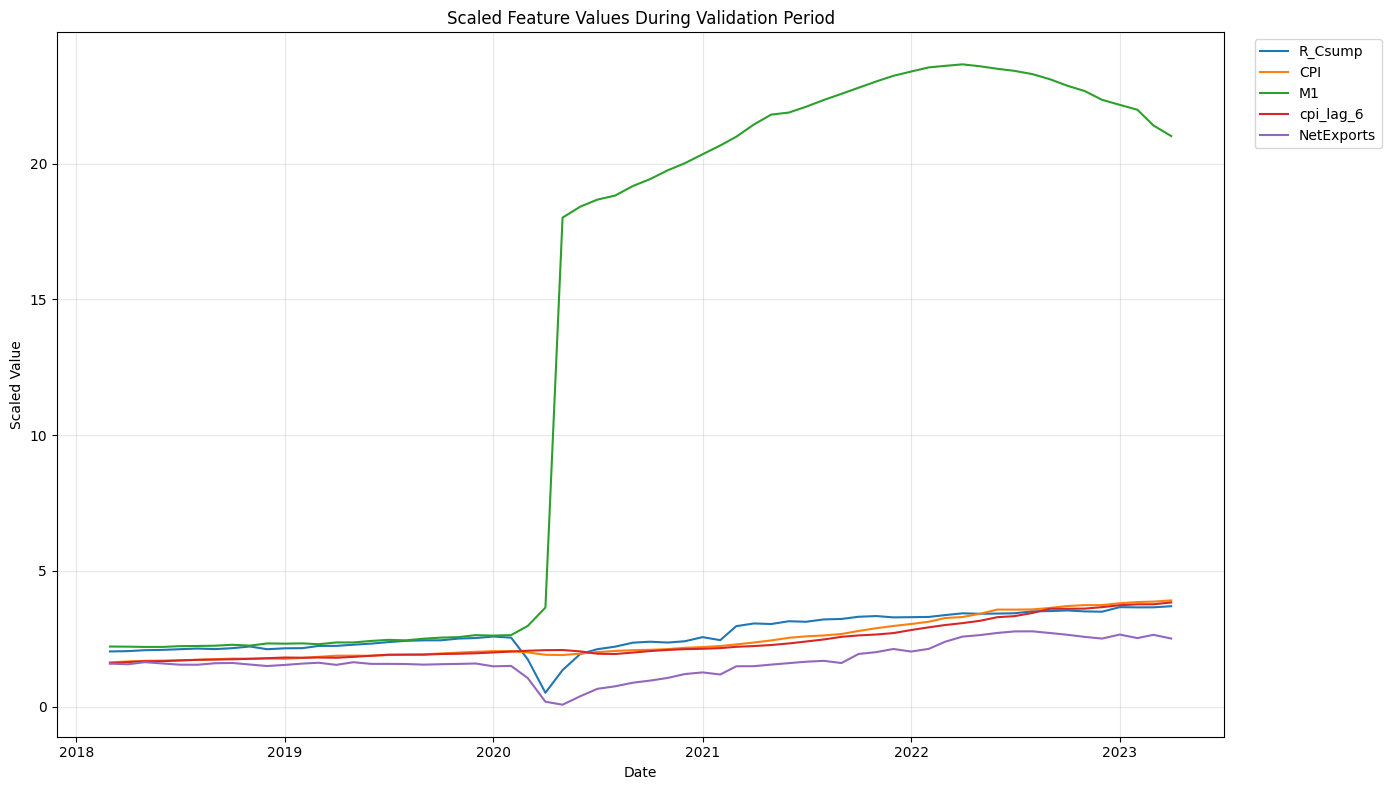

In [70]:
import matplotlib.pyplot as plt

top_features = [
    "R_Csump",
    "CPI",
    "M1",
    "cpi_lag_6",
    "NetExports",

]

val_scaled_plot = X_val_scaled.copy()
val_scaled_plot["DATE"] = dates_val.values
val_scaled_plot = val_scaled_plot.sort_values("DATE").reset_index(drop=True)

plt.figure(figsize=(14, 8))

for col in top_features:
    plt.plot(val_scaled_plot["DATE"], val_scaled_plot[col], label=col, linewidth=1.5)

plt.title("Scaled Feature Values During Validation Period")
plt.xlabel("Date")
plt.ylabel("Scaled Value")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


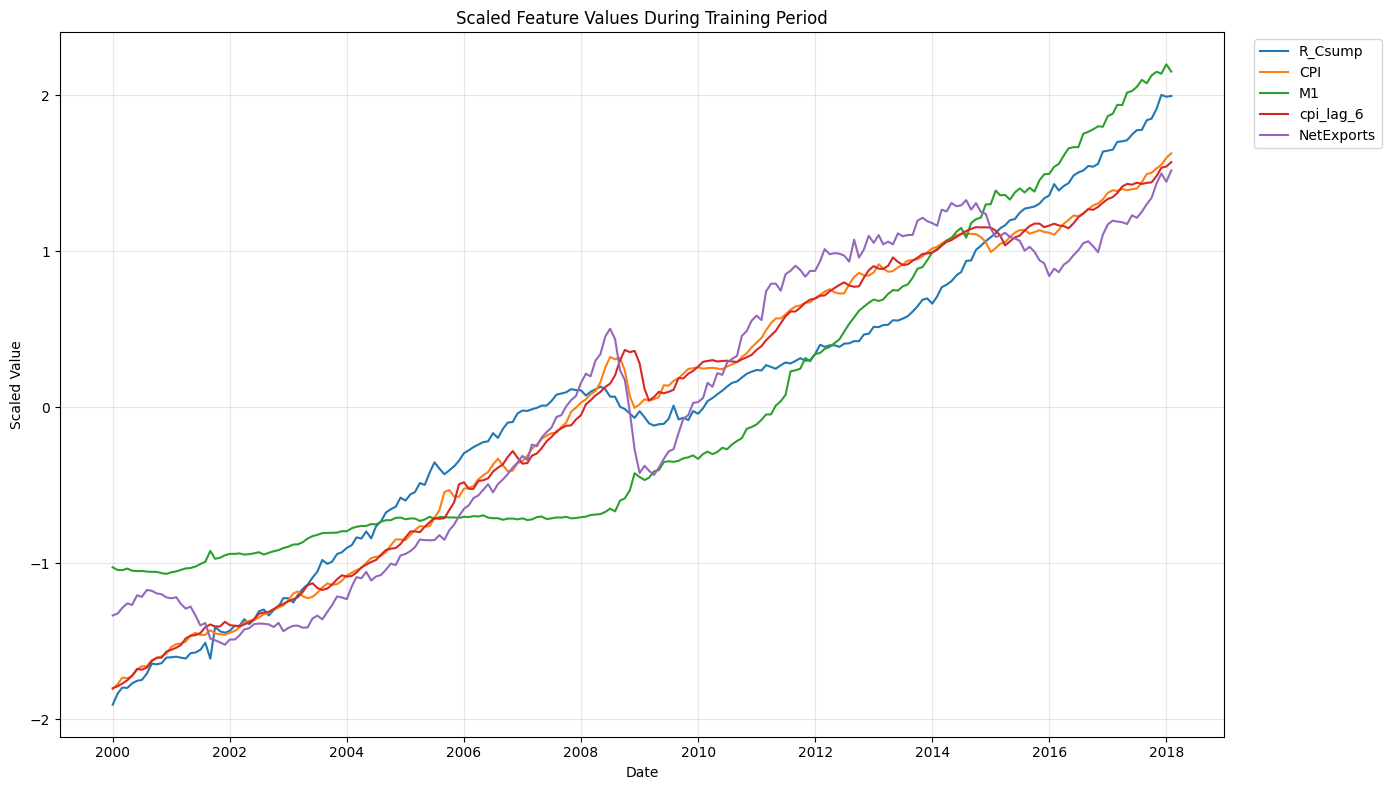

In [71]:
import matplotlib.pyplot as plt

top_features = [
    "R_Csump",
    "CPI",
    "M1",
    "cpi_lag_6",
    "NetExports",
]

top_features = [col for col in top_features if col in X_train_scaled.columns]

train_scaled_plot = X_train_scaled.copy()
train_scaled_plot["DATE"] = dates_train.values
train_scaled_plot = train_scaled_plot.sort_values("DATE").reset_index(drop=True)

plt.figure(figsize=(14, 8))

for col in top_features:
    plt.plot(train_scaled_plot["DATE"], train_scaled_plot[col], label=col, linewidth=1.5)

plt.title("Scaled Feature Values During Training Period")
plt.xlabel("Date")
plt.ylabel("Scaled Value")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
